# Week 4 Day 1 — Positional Encoding
**Jul 20, 2026**

Finishing the transformer arc from Week 3. First problem to fix: self-attention has no idea what order its inputs came in. Today: prove that concretely, then fix it with sinusoidal positional encoding.

Scaffold as usual: TODO stubs, hints not formulas, self-check cells.

## Part 1: Self-attention doesn't know about order

Given. Take a sequence, shuffle it, run both through the same (untrained) self-attention module, and compare.

In [1]:
import torch
import torch.nn as nn
import math

torch.manual_seed(0)

class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        Q, K, V = self.q_proj(x), self.k_proj(x), self.v_proj(x)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(Q.shape[-1])
        weights = torch.softmax(scores, dim=-1)
        return weights @ V

d_model, seq_len = 16, 4
attn = SelfAttention(d_model)
x = torch.randn(1, seq_len, d_model)

perm = torch.tensor([2, 0, 3, 1])  # some arbitrary reordering
x_perm = x[:, perm, :]

out = attn(x)
out_perm = attn(x_perm)
out_permuted_manually = out[:, perm, :]  # take the ORIGINAL output and reorder it the same way

print("attention(shuffled input) == shuffled attention(input)?",
      torch.allclose(out_perm, out_permuted_manually, atol=1e-6))

attention(shuffled input) == shuffled attention(input)? True


`True` means attention is *permutation-equivariant*: shuffle the input, and the output is exactly the same values, just shuffled the same way. Every token's output only depends on *which* tokens are present (as a set) and their content, never on the order they appear in. A word at the start of a sentence and the same word at the end would get treated identically by this mechanism -- clearly wrong for language, where order carries meaning ("dog bites man" vs "man bites dog").

## Part 2: Sinusoidal positional encoding

TODO: implement `sinusoidal_positional_encoding(seq_len, d_model)`, returning a `(seq_len, d_model)` tensor. This is the fixed (non-learned) scheme from the original "Attention Is All You Need" paper -- a specific formula, not something to derive, so it's given here rather than hinted at:

For position `pos` (0-indexed) and dimension index `i`:
```
PE[pos, 2i]   = sin(pos / 10000^(2i / d_model))
PE[pos, 2i+1] = cos(pos / 10000^(2i / d_model))
```
Even dimensions get `sin`, odd dimensions get `cos`, and the "frequency" (how fast the wave oscillates as `pos` increases) varies smoothly across the `d_model` dimensions -- low dimensions oscillate fast, high dimensions oscillate slowly. Every position ends up with a unique vector, and — as a side effect of using sinusoids specifically rather than an arbitrary unique-per-position scheme — the pattern generalizes cleanly to sequence lengths never seen during training.

Implementation note: `torch.arange(0, d_model, 2)` gives you the even indices directly; computing `10000^(2i/d_model)` is more numerically stable as `exp(2i * -log(10000) / d_model)` than a literal power operation, since it avoids computing a huge number and then a tiny one.

In [ ]:
def sinusoidal_positional_encoding(seq_len, d_model):
    # TODO: return a (seq_len, d_model) tensor per the formula above
    position = torch.arange(seq_len, dtype=torch.float32).unsqueeze(1)
    
    # Frequencies for each dimension
    # Frequencies for dimension pairs: (0,1), (2,3), ...
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float32)
        * (-torch.log(torch.tensor(10000.0)) / d_model)
    )
    
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)  # even
    pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
    return pe


pe = sinusoidal_positional_encoding(10, 16)
assert pe.shape == (10, 16), f"expected (10, 16), got {tuple(pe.shape)}"
assert pe.min() >= -1 and pe.max() <= 1, "sin/cos output should be bounded in [-1, 1]"
assert len(torch.unique(pe, dim=0)) == 10, "every position should get a distinct encoding"

# pos=0: sin(0)=0, cos(0)=1 for every dimension pair
expected_row0 = torch.tensor([0., 1., 0., 1., 0., 1.])
assert torch.allclose(pe[0][:6], expected_row0, atol=1e-6), f"pe[0] should start {expected_row0}, got {pe[0][:6]}"

print("sinusoidal_positional_encoding OK")

sinusoidal_positional_encoding OK


## Part 3: Confirm it actually fixes Part 1

TODO: add the positional encoding to `x` (and to `x_perm`) before running it through `attn`, and rerun Part 1's comparison. The two versions should now genuinely differ -- position now carries information the mechanism can use.

One subtlety worth being deliberate about: when you build `x_perm`'s positionally-encoded version, add the *same* `pe` (indexed by slot 0, 1, 2, 3) to the *already-shuffled* content -- i.e. position encoding is added per output slot, not carried along with a token's original identity. That's what makes this a fair test of "does the model now know slot order," rather than accidentally testing something else.

In [ ]:
pe4 = sinusoidal_positional_encoding(seq_len, d_model)

# TODO: x_with_pe = x + ...
x_with_pe = x + pe4.unsqueeze(0)  # Add positional encoding to the input
# TODO: x_perm_with_pe = x[:, perm, :] + ...
x_perm_with_pe = x[:, perm, :] + pe4.unsqueeze(0)  # Add positional encoding to the permuted input

out_with_pe = attn(x_with_pe)
out_perm_with_pe = attn(x_perm_with_pe)
out_permuted_manually_pe = out_with_pe[:, perm, :]

still_invariant = torch.allclose(out_perm_with_pe, out_permuted_manually_pe, atol=1e-6)
print("still permutation invariant after adding positional encoding?", still_invariant)
assert not still_invariant, "positional encoding should have broken the symmetry from Part 1"
print("confirmed: positional encoding gives the model access to order")

still permutation invariant after adding positional encoding? False
confirmed: positional encoding gives the model access to order


## Part 4: What the encoding looks like

Given. The classic striped visualization -- each row is one position's encoding vector, each column a dimension.

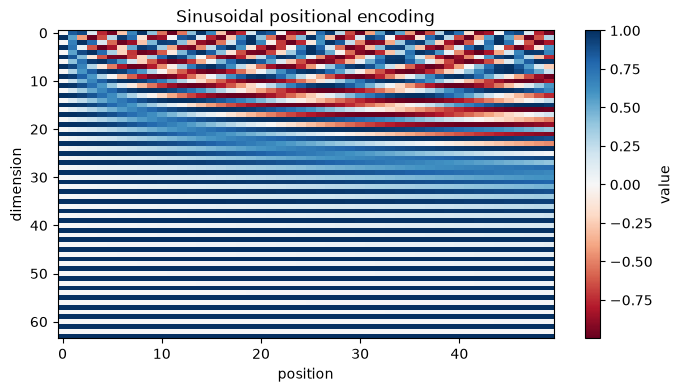

In [6]:
import matplotlib.pyplot as plt

pe_viz = sinusoidal_positional_encoding(50, 64)
plt.figure(figsize=(8, 4))
plt.imshow(pe_viz.T, cmap="RdBu", aspect="auto")
plt.xlabel("position"); plt.ylabel("dimension")
plt.colorbar(label="value")
plt.title("Sinusoidal positional encoding")
plt.show()

## Try yourself

1. Build a *learned* alternative: `nn.Embedding(max_len, d_model)`, indexed by position `0..seq_len-1`. Wire it in place of the sinusoidal version in Part 3 and confirm it also breaks permutation invariance. What's the practical tradeoff -- what can the sinusoidal version do that a learned embedding table capped at `max_len` positions can't?
2. Verify a real property of the sinusoidal scheme: for a fixed offset `k`, `PE[pos+k]` can be written as a linear function of `PE[pos]` (a rotation, roughly). Pick a `k`, and numerically check `PE[pos+k]` against `PE[pos]` transformed by a fitted linear map -- does it hold?
3. Feed a sequence *longer* than anything used above through `sinusoidal_positional_encoding` (e.g. `seq_len=500`) -- no errors, no retraining needed. Now imagine trying the same with the learned embedding table from #1 at a length beyond `max_len` -- what breaks?
4. Wire `sinusoidal_positional_encoding` into Week 3 Day 7's full `EncoderBlock` (add it to the input before the first block) and confirm the shapes still work end to end.